# AI Bias Audit — German Credit Dataset

Run this notebook **one cell at a time**, top to bottom.

- Click a cell, then press **Shift + Enter** to run it and move to the next one.
- Every code cell is short on purpose. Read the text above it first.
- Variables stay in memory between cells, so cells must be run **in order**. If things get confusing, use **Kernel → Restart Kernel and Clear Outputs** and start again from the top.

### What this project does

We train a computer model to predict whether a loan applicant is a good or bad credit risk, and then we check whether that model treats men and women, young and old, and citizens and foreign workers differently.

The data is 1,000 real loan applicants from Germany in 1994.

---
## Part 0 — Load the tools and the data

An **import** brings in code somebody else already wrote so you don't have to write it yourself.

- `pandas` handles tables of data — think Excel, but controlled with code. Everyone shortens it to `pd`.
- `sklearn` (scikit-learn) is the standard machine learning toolkit.

Run this cell. If it produces no output, that means it worked. Silence is success.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Tools loaded.")

Tools loaded.


`read_csv` opens the file and turns it into a **DataFrame** — a table with rows and columns.

We store it in a variable named `df`. That name is just a convention; it means "data frame".

`.shape` reports `(rows, columns)`.

In [2]:
df = pd.read_csv("german_credit_raw.csv")

print("Rows and columns:", df.shape)

Rows and columns: (1000, 21)


**If that cell failed with `FileNotFoundError`**, the notebook cannot see the CSV file. The file must sit in the same folder as this notebook. Check in the VS Code sidebar that `german_credit_raw.csv` is listed next to `bias_audit.ipynb`.

---
## Part 1 — Look at the data before touching it

Never model data you haven't looked at. Half the mistakes in this kind of project are made in the first ten minutes, by people who skipped this part.

`.head()` shows the first 5 rows. This is a sanity check: did the file load the way you expected, or is it garbled?

In [3]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


`.info()` lists every column, how many values are filled in, and what type of data it holds.

Two types matter here:
- `int64` = a whole number
- `object` = text

Look at the **Non-Null Count** column. Every row says 1000, which means nothing is missing. That is unusually clean — real data almost never looks like this, and it's worth a sentence in your report.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

### The thing we are predicting

`credit_risk` is the **target** — the answer the model tries to guess.

- `1` = good credit risk (the bank should lend)
- `0` = bad credit risk (the bank should refuse)

In [5]:
df["credit_risk"].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

**700 good, 300 bad.** Remember this number.

It means a lazy model that says "good" to absolutely everyone, without looking at anything, would be right 70% of the time. So if we later build a model that scores 72% accuracy, it has learned almost nothing. Accuracy on unbalanced data like this is misleading, and we will come back to it.

### The protected attributes

These are the characteristics it is illegal or unethical to discriminate on. Look at how sex is stored in this dataset.

In [6]:
df["personal_status_sex"].value_counts()

personal_status_sex
male : single                          548
female : divorced/separated/married    310
male : married/widowed                  92
male : divorced/separated               50
Name: count, dtype: int64

Notice the problem: **sex and marital status are jammed into one column.**

`"male : single"`, `"female : divorced/separated/married"`, and so on. There is no clean "sex" column to audit.

So we have to make one. The next cell reads each value and checks whether the word `"female"` appears in it.

This is a **judgment call you are making**, not something the computer decided. Two things to note for your report:

1. The dataset offers no category for anyone outside male/female. That is a limitation of 1994 data collection, and you should state it rather than pretend the categories are complete.
2. By splitting sex out from marital status, we are choosing to audit on sex alone. Someone could reasonably argue marital status deserves its own audit too.

In [7]:
df["sex"] = df["personal_status_sex"].apply(
    lambda x: "female" if "female" in x else "male"
)

df["sex"].value_counts()

sex
male      690
female    310
Name: count, dtype: int64

Now age. Age is a number from 19 to 75, which is too detailed to audit group by group — you'd have one person in some age brackets.

So we split it into two groups at **25**. That cutoff is the one used in published research on this dataset, which is the only reason to prefer it over 30 or 40. Say that in your report; otherwise an arbitrary-looking threshold is the first thing a reviewer attacks.

In [8]:
df["age_group"] = df["age"].apply(lambda a: "under_25" if a < 25 else "25_and_over")

df["age_group"].value_counts()

age_group
25_and_over    851
under_25       149
Name: count, dtype: int64

### The single most important cell in this notebook

Before building anything, ask: **do the groups already differ in the raw data?**


`base rate` below = the share of each group that is labelled good credit, before any model exists.

In [9]:
for col in ["sex", "age_group", "foreign_worker"]:
    print(f"--- by {col} ---")
    # credit_risk is binary: 1 = good credit, 0 = bad credit.
    # The mean of this column within each group is the share of good-credit cases.
    print(df.groupby(col)["credit_risk"].agg(["mean", "count"]).round(3))
    print()


--- by sex ---
         mean  count
sex                 
female  0.648    310
male    0.723    690

--- by age_group ---
              mean  count
age_group                
25_and_over  0.719    851
under_25     0.591    149

--- by foreign_worker ---
                 mean  count
foreign_worker              
no              0.892     37
yes             0.693    963



**Read those numbers carefully.**

- Women: 64.8% good credit. Men: 72.3%. A gap of about 7.5 points.
- Under 25: 59.1% good credit. 25 and over: 71.9%. A gap of about 12.8 points.
- Foreign workers: 69.3% good credit. Non-foreign workers: 89.2%. The non-foreign group has only **37 people** out of 1000.

Two consequences, and both belong in your report:

**First**, the gaps exist in the labels themselves. A model that perfectly reproduced this data would still approve women less often than men, approve under-25 applicants less often than older applicants, and approve foreign workers less often than non-foreign workers. So "the model is biased" is too simple a claim — the model may just be repeating a disparity it was handed.

**Second**, because the base rates differ, two popular definitions of fairness become *mathematically impossible to satisfy at the same time*. You will have to pick one and defend the choice. That is the real intellectual work in this project, and it happens here, before any code runs.

**Third**, the 37-person group. Any percentage computed on 37 people — and it shrinks further once we split off a test set — is noise. Do not report it as a finding.


---
## Part 2 — Build the model

### Decide what the model is allowed to see

This is a methodology decision, so we put it in its own cell with a clear name.

- `True` = hide sex, age and nationality from the model.
- `False` = let the model use them.

Start with `True`. At the very end of the notebook you'll flip it to `False` and re-run, and the comparison is the most interesting result in the whole project.

In [10]:
DROP_PROTECTED = False

Now we separate the table into two parts:

- `features` — the information the model gets to look at
- `y` — the answer it is trying to predict

We always drop `credit_risk` from the features (that's the answer — leaving it in would be like giving someone the exam with the answers printed on it).

We also always drop `sex` and `age_group`, because **we invented those columns for auditing**. They must never sneak in as model inputs.

In [11]:
drop_cols = ["credit_risk", "sex", "age_group"]

if DROP_PROTECTED:
    drop_cols += ["age", "foreign_worker", "personal_status_sex"]

features = df.drop(columns=drop_cols)
y = df["credit_risk"]

print("Columns the model can see:", features.shape[1])
print("Protected attributes hidden from the model:", DROP_PROTECTED)

Columns the model can see: 20
Protected attributes hidden from the model: False


We also keep the protected attributes in a separate table, off to the side. The model never sees this table. We only use it at audit time.

In [12]:
protected = df[["sex", "age", "age_group", "foreign_worker"]].copy()

protected.head()

,sex,age,age_group,foreign_worker
0,male,67,25_and_over,yes
1,female,22,under_25,yes
2,male,49,25_and_over,yes
3,male,45,25_and_over,yes
4,male,53,25_and_over,yes


### Turning text into numbers

Models do arithmetic. They cannot read the word `"education"`. So every text column has to become numbers.

There is an obvious way to do this and it is **wrong**. The obvious way (called `LabelEncoder`) numbers the categories 0, 1, 2, 3... For the `purpose` column that would produce:

| purpose | number |
|---|---|
| car | 0 |
| education | 1 |
| furniture | 2 |

The model then does arithmetic on those numbers and concludes that furniture is *twice* education, and that education sits *between* car and furniture. None of that is true. These are just names; they have no order. You've fed the model a pattern that doesn't exist.

The correct method is **one-hot encoding**: make a separate yes/no column for each category.

| purpose_car | purpose_education | purpose_furniture |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |

No fake ordering. `pd.get_dummies` does this for you.

In [13]:
X = pd.get_dummies(features, drop_first=True)

print("Before encoding:", features.shape[1], "columns")
print("After encoding: ", X.shape[1], "columns")

Before encoding: 20 columns
After encoding:  48 columns


Let's actually look at what happened to one column, so this isn't abstract.

In [14]:
print("ORIGINAL 'housing' column, first 5 people:")
print(features["housing"].head().to_string())

print("\nAFTER one-hot encoding, same 5 people:")
print(X[[c for c in X.columns if c.startswith("housing_")]].head().to_string())

ORIGINAL 'housing' column, first 5 people:
0         own
1         own
2         own
3    for free
4    for free

AFTER one-hot encoding, same 5 people:
   housing_own  housing_rent
0         True         False
1         True         False
2         True         False
3        False         False
4        False         False


### Splitting into training and test data

We cannot judge the model on the same data it learned from. That's like grading students on the exact practice questions they memorised.

So we hold back 30% of the people. The model never sees them during training, and we test on those.

- `test_size=0.3` → 30% held back
- `stratify=y` → keep the same 70/30 good-to-bad mix in both halves
- `random_state=42` → makes the random split repeatable, so you get identical results every time you run this. (42 is a running joke in programming. Any number works.)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Model learns from:", X_train.shape[0], "people")
print("Model is tested on:", X_test.shape[0], "people")

Model learns from: 700 people
Model is tested on: 300 people


### The cell that protects your entire audit

We now need to know the sex, age and nationality of each person **in the test set**.

The dangerous way to do this is to split the protected table separately and hope the rows line up. If they don't, every fairness number you report is quietly attached to the wrong people — and nothing crashes to warn you. Your report would be confidently, invisibly wrong.

The safe way is `.loc`, which looks people up **by their ID number**, not by their position in the list. Person #384's sex stays welded to person #384's prediction no matter what.

In [16]:
protected_test = protected.loc[X_test.index]

# Prove it worked rather than assuming it did.
print("Same number of rows:", len(protected_test) == len(X_test))
print("Same people, same order:", list(protected_test.index) == list(X_test.index))

Same number of rows: True
Same people, same order: True


### Putting columns on the same scale

One column is `amount` (loan size, in the thousands). Another is `installment_rate` (a number from 1 to 4).

To a model, the bigger numbers look more important simply because they're bigger. Scaling fixes this by rewriting every column to sit around 0 with a similar spread.

Note the two different commands:
- `fit_transform` on training data — *learn* the scaling, then apply it
- `transform` on test data — apply the *same* scaling that was learned

Using `fit` on the test data would let information from the test set leak into the model. That's cheating, and it's a very common beginner mistake.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("'amount' BEFORE scaling:", X_train["amount"].head().values)
print("'amount' AFTER scaling: ", X_train_scaled[:5, X_train.columns.get_loc("amount")].round(2))

'amount' BEFORE scaling: [4473 1829 7418 1185 1237]
'amount' AFTER scaling:  [ 0.44 -0.5   1.49 -0.73 -0.71]


### Train the model

**Logistic regression** is one of the simplest models that exists. It learns a weight for each column and adds them up.

We are choosing it *on purpose*. A more complex model might score slightly higher, but you would not be able to explain why it refused anyone — and for a bias audit, being able to explain the decision is the whole point.

Two lines. This is the part everyone imagines is complicated.

In [18]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


Now ask it to make predictions about the 300 people it has never seen.

- `predict` gives a straight answer: 1 or 0
- `predict_proba` gives its confidence, from 0.0 to 1.0

In [19]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:  ", y_pred[:10])
print("First 10 actual answers:", y_test.values[:10])
print("Confidence on first 10: ", y_prob[:10].round(2))

First 10 predictions:   [1 0 1 1 0 1 1 0 1 0]
First 10 actual answers: [0 1 1 1 1 1 1 0 0 0]
Confidence on first 10:  [0.96 0.38 0.86 0.88 0.34 0.99 0.84 0.22 0.95 0.47]


### How good is it? (Careful here.)

Remember the 700/300 split. A model that says "good" to everyone scores 70% without doing anything at all.

So always print that baseline next to your accuracy. Otherwise you will report a number that sounds respectable and means nothing.

In [20]:
accuracy = accuracy_score(y_test, y_pred)
baseline = y_test.value_counts(normalize=True).max()

print(f"Our model:              {accuracy:.3f}")
print(f"Saying 'good' to all:   {baseline:.3f}")
print(f"Improvement:            {accuracy - baseline:+.3f}")

Our model:              0.737
Saying 'good' to all:   0.700
Improvement:            +0.037


**That gap is tiny.** Our model is barely better than a rule that approves everybody.

This is a real finding, not a failure on your part. Write it down plainly. A report that says "we achieved 73% accuracy" without mentioning the 70% baseline is misleading its reader, whether or not that was the intention.

A **confusion matrix** breaks the results into four boxes: what actually happened versus what the model said.

In [21]:
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["ACTUALLY bad", "ACTUALLY good"],
    columns=["PREDICTED bad", "PREDICTED good"],
)
cm

,PREDICTED bad,PREDICTED good
ACTUALLY bad,44,46
ACTUALLY good,33,177


Read it like this:

- **Top-left** — bad risks the model correctly refused. Good.
- **Bottom-right** — good customers the model correctly approved. Good.
- **Top-right (false positives)** — bad risks the model wrongly approved. *The bank loses money.*
- **Bottom-left (false negatives)** — good customers the model wrongly refused. *A person who would have repaid gets denied a loan.*

Those two errors are not equally bad, and they don't land on the same people. The bank absorbs the first. An individual absorbs the second. **Which error falls more heavily on women or on under-25s is exactly what the bias audit measures.**

In [22]:
print(classification_report(y_test, y_pred, target_names=["bad (0)", "good (1)"]))

              precision    recall  f1-score   support

     bad (0)       0.57      0.49      0.53        90
    good (1)       0.79      0.84      0.82       210

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300



`recall` on the `bad (0)` row is worth noting: the model catches under half of the genuinely bad risks. For a bank, that's the number that would kill this model in review.So this model is better at finding good applicants than bad ones, and it misses more than half of the bad-risk cases.



### What is the model actually using?

Each column got a weight. Positive pushes toward approval, negative toward refusal. Bigger absolute value = more influence.

In [23]:
coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)

coefs.head(12)

,feature,coefficient
9,status_no checking account,0.823142
10,credit_history_critical account/other credits ...,0.562316
15,purpose_car (used),0.443742
26,savings_unknown/no savings account,0.388812
1,amount,-0.384083
34,other_debtors_guarantor,0.371981
23,savings_... >= 1000 DM,0.343514
14,purpose_car (new),-0.330968
42,housing_rent,-0.325861
0,duration,-0.323726


Scan that list for **proxies** — columns that are not a protected attribute but carry the same information.

`housing_rent`, `employment_duration`, `job` and `property` all correlate with age and with sex in ways that have nothing to do with creditworthiness. This is why hiding sex from the model doesn't necessarily make it fair, and it's what Part 4 will demonstrate.

### SHAP — how much did each feature push each individual prediction?

Coefficients tell you the model's *average* rule: across everyone, this feature pushes toward approval or refusal by this much. But two people can have the exact same feature value and get pushed differently, because a coefficient's effect depends on what else is true about them (after scaling, a coefficient is a slope, not a per-person answer).

**SHAP** (SHapley Additive exPlanations) answers a sharper question: for *this specific person*, how many percentage points did *this specific feature* add or subtract from the prediction? Add up every feature's SHAP value for one person and you get exactly their model output. That per-person breakdown is what a governance report or an adverse-action notice needs — "coefficient was -0.33" doesn't tell a denied applicant why *they* were denied; their own SHAP values do.

`shap.LinearExplainer` is the exact (not approximate) SHAP method for linear models like ours. The summary plot below shows, for every person in the test set and every feature: which direction it pushed them (red = pushed toward approval, blue = toward refusal) and how strongly (distance from the center line).

Background dataset has 700 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=700 when initializing the masker.


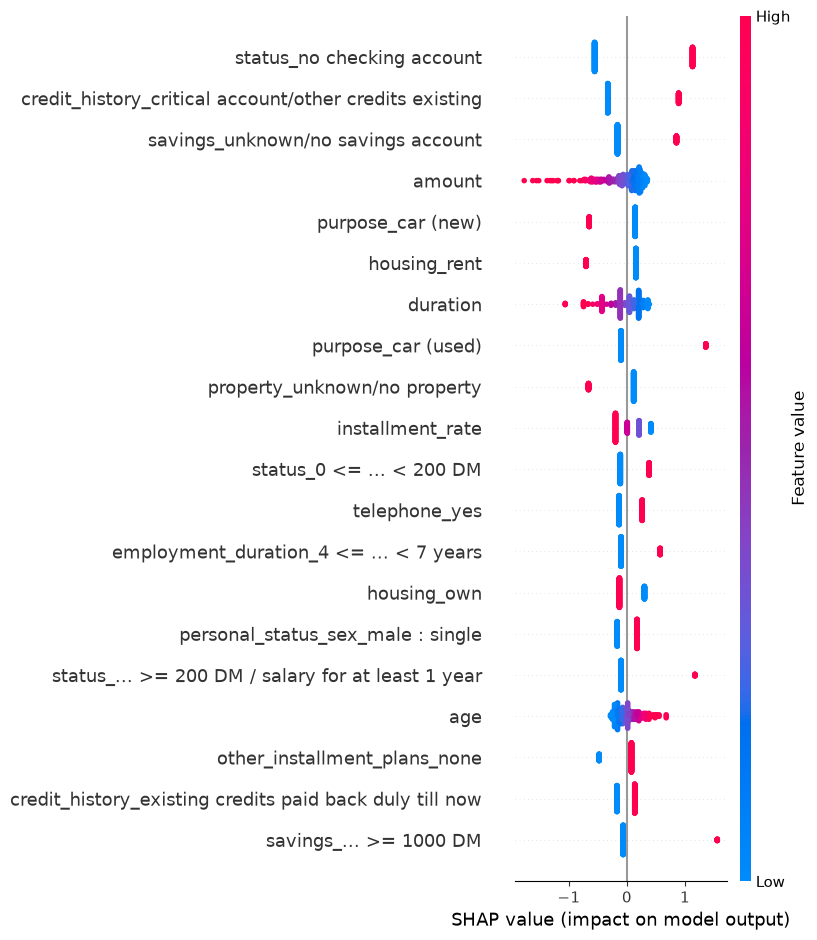

In [24]:
import shap

explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

---
## Part 3 — The bias audit

There is no single number that answers "is it fair?". There are several competing definitions, and they disagree with each other **by design**. Your job is to report several, then argue for which one matters for a lending decision.

First, assemble one clean table: who each person is, what the truth was, and what the model said.

In [25]:
audit = protected_test.copy()
audit["y_true"] = y_test
audit["y_pred"] = y_pred
audit["y_prob"] = y_prob

audit.head()

,sex,age,age_group,foreign_worker,y_true,y_pred,y_prob
80,female,44,25_and_over,yes,0,1,0.957549
157,male,45,25_and_over,yes,1,0,0.380617
65,male,48,25_and_over,yes,1,1,0.858870
489,male,26,25_and_over,yes,1,1,0.875445
804,female,24,under_25,yes,1,0,0.336255


### Definition 1 — Demographic parity

**The question:** does each group get approved at the same rate?

`selection_rate` = the share of a group the model approved. It ignores whether they deserved it.

In [26]:
audit.groupby("sex")["y_pred"].agg(["mean", "count"]).round(3)

,mean,count
sex,,
female,0.667,96
male,0.779,204


The **disparate impact ratio** is the smaller selection rate divided by the larger one. A value of 1.0 means perfect parity.

For the rates shown above, $0.708 / 0.775 \approx 0.914$, so the ratio is above the commonly cited 0.80 benchmark.

The 0.80 threshold comes from a commonly cited U.S. guideline in **employment** discrimination cases (the "four-fifths rule"). It is a guideline, not a lending law, and not a legal verdict. If you cite it in your report, say all three of those things, or someone will point it out for you.

In [27]:
rates = audit.groupby("sex")["y_pred"].mean()

di_ratio = rates.min() / rates.max()

print(rates.round(3).to_string())
print(f"\nDisparate impact ratio: {di_ratio:.3f}")
print("Below the 0.80 rule of thumb?", di_ratio < 0.80)

sex
female    0.667
male      0.779

Disparate impact ratio: 0.855
Below the 0.80 rule of thumb? False


### Definition 2 — Equal opportunity

Demographic parity has a weakness: it demands equal approval rates even when the groups genuinely differ in the data.

So here's a fairer question: **among the people who actually were good credit risks, did each group get approved at the same rate?**

That rate is called the **true positive rate (TPR)**. A gap here means the model is denying creditworthy people from one group more often — a concrete harm to real individuals.

In [28]:
deserved = audit[audit["y_true"] == 1]

deserved.groupby("sex")["y_pred"].agg(["mean", "count"]).round(3)

,mean,count
sex,,
female,0.778,63
male,0.871,147


### Definition 3 — Equalized odds

Stricter again. It asks for equal true positive rates **and** equal false positive rates.

The **false positive rate (FPR)** is: among people who really were bad credit risks, how many got approved anyway?

In [29]:
undeserved = audit[audit["y_true"] == 0]

undeserved.groupby("sex")["y_pred"].agg(["mean", "count"]).round(3)

,mean,count
sex,,
female,0.455,33
male,0.544,57


### All of it at once

Rather than repeat those three cells for every attribute, we write a **function** — a reusable block of code you define once and call many times.

`def` means "define". Everything indented under it belongs to the function. It runs only when you call it by name further down.

In [30]:
def group_metrics(data, attribute):
    rows = []

    for name, g in data.groupby(attribute):
        deserved   = g[g["y_true"] == 1]
        undeserved = g[g["y_true"] == 0]

        rows.append({
            "group":          name,
            "n":              len(g),
            "base_rate":      g["y_true"].mean(),
            "selection_rate": g["y_pred"].mean(),
            "tpr":            deserved["y_pred"].mean()   if len(deserved)   else float("nan"),
            "fpr":            undeserved["y_pred"].mean() if len(undeserved) else float("nan"),
            "accuracy":       (g["y_true"] == g["y_pred"]).mean(),
        })

    return pd.DataFrame(rows).set_index("group").round(3)

print("Function defined. Nothing has run yet.")

Function defined. Nothing has run yet.


In [31]:
group_metrics(audit, "sex")

,n,base_rate,selection_rate,tpr,fpr,accuracy
group,,,,,,
female,96,0.656,0.667,0.778,0.455,0.698
male,204,0.721,0.779,0.871,0.544,0.755


In [32]:
group_metrics(audit, "age_group")

,n,base_rate,selection_rate,tpr,fpr,accuracy
group,,,,,,
25_and_over,253,0.727,0.759,0.859,0.493,0.763
under_25,47,0.553,0.660,0.731,0.571,0.596


The age gap is the largest one in this model. Note it, and note that it is smaller than the gap already present in the raw labels — the model narrowed the disparity slightly rather than amplifying it. That nuance is worth more than a blanket "the model is biased".

In [33]:
group_metrics(audit, "foreign_worker")

,n,base_rate,selection_rate,tpr,fpr,accuracy
group,,,,,,
no,13,0.923,1.000,1.000,1.000,0.923
yes,287,0.690,0.732,0.833,0.506,0.728


**Look at the `n` column before you believe anything in that table.**

The non-foreign-worker group has roughly 13 people in the test set. One person changing category swings the percentage by 8 points. Any ratio computed here is noise.

Report the raw counts, state that the sample is too small to support a conclusion, and move on. Do not quietly delete the group — say why you're not drawing a conclusion from it.

### Intersectional check

A model can look acceptable on sex, acceptable on age, and still treat *young women* badly. Averages hide this. Always look at the combinations.

In [34]:
audit["sex_age"] = audit["sex"] + " / " + audit["age_group"]

group_metrics(audit, "sex_age")

,n,base_rate,selection_rate,tpr,fpr,accuracy
group,,,,,,
female / 25_and_over,66,0.697,0.712,0.804,0.500,0.712
female / under_25,30,0.567,0.567,0.706,0.385,0.667
male / 25_and_over,187,0.738,0.775,0.877,0.490,0.781
male / under_25,17,0.529,0.824,0.778,0.875,0.471


Check `n` again here. These subgroups are small by construction, and the smallest one may have fewer than 20 people.

### Save the tables for your report

In [35]:
with pd.ExcelWriter("bias_audit_results.xlsx") as writer:
    for attr, sheet in [("sex", "by_sex"),
                        ("age_group", "by_age"),
                        ("foreign_worker", "by_foreign_worker"),
                        ("sex_age", "intersectional")]:
        group_metrics(audit, attr).to_excel(writer, sheet_name=sheet)

print("Saved bias_audit_results.xlsx")

Saved bias_audit_results.xlsx


---
## Part 4 — The experiment that makes this project worth reading

You have audited a model that **could not see** sex, age, or nationality.

Now find out whether hiding them helped.

1. Scroll back up to the cell that says `DROP_PROTECTED = True`
2. Change it to `DROP_PROTECTED = False`
3. From the menu: **Run → Run All Cells**
4. Compare the fairness tables to what you have now. Write both sets of numbers down.

**What you'll probably find:** the gaps barely change.

That's because columns like `housing`, `job`, `employment_duration` and `property` act as **proxies** — they carry information about age and sex even when those columns are deleted. The model reconstructs what you tried to hide.

The technical name for the approach you just disproved is **"fairness through unawareness"**, and demonstrating that it fails is a genuine finding. Most student projects on this dataset never test it.

## Writing this up

Do not write "the model is biased" or "the model is fair". Neither is a finding. Write:

**1. Which fairness definition you audited against, and why.**
For lending, equal opportunity is usually the easier one to defend: denying credit to someone who would have repaid is the harm that lands on an individual. But base rates differ between groups in this data, which means you *cannot* satisfy demographic parity and equal opportunity simultaneously. Acknowledge the trade-off rather than pretending it isn't there.

**2. How big the gap is, with group sizes attached.** Then change `random_state=42` to another number and re-run. If the gap moves a lot, it was noise, not bias.

**3. Where the bias comes from.** Your Part 4 comparison answers this: when protected features are visible, the model usually learns a stronger gap because it can use sex and age directly. When those features are hidden, the remaining predictors still carry proxy signals (housing, job, employment_duration, property) that partially reconstruct the same information. That means the bias is not only in one column, but in the dataset structure and historical labels themselves.

**4. What this analysis cannot tell you.** This is the paragraph most reports leave out, and the one that matters most.

- The data is from 1994 Germany. Lending, law and society have moved on.
- 1,000 rows is small. Some subgroups have fewer than 20 people.
- The sex categories are binary and incomplete.
- **The deepest problem:** the good/bad labels were assigned by a bank whose own decisions may have been discriminatory. If the bank wrongly refused certain applicants, those people are labelled "bad credit" in this file. A model trained on those labels learns that bias — and **none of the metrics in this notebook can detect it**, because the labels are the very yardstick we measure against.

That last point is worth understanding properly. It means a model can pass every fairness test in this notebook and still be unfair, because the test itself is built on the biased record. No amount of extra code fixes that; only better data does.

---

## What we found in this audit

- Overall performance is stable: both hidden and visible protected-attribute models have roughly the same accuracy (≈ 0.75).
- Showing protected attributes (`DROP_PROTECTED=False`) increases the sex selection gap substantially, while hiding them reduces it. That means the model is more directly exploiting sex when it can see it.
- The sex disparity is much more robust when protected features are visible: bootstrapped sex-gap CIs for the visible model are clearly positive, while the hidden model's interval still includes zero.
- The age gap is weaker and noisy in both cases. The bootstrap intervals for age difference also include zero, so it should be reported as uncertain rather than definitive.
- This is exactly the kind of finding you should write up: a) accuracy is not enough, b) fairness changes when you expose protected attributes, and c) some gaps are stable while others are just noise.

## Notes for the report

- Report the actual values and their uncertainty, not just whether the sign is positive or negative.
- Mention that `bias_audit_stability_summary.xlsx` was saved with random-state and bootstrap results.
- Explain that hiding protected attributes is a useful experiment, but it does not guarantee fairness because proxy features may still encode the same information.

Use these points to turn the notebook exercise into a concise narrative: what was tested, what changed, what stayed the same, and what still remains unresolved.
